In [23]:
start_n = 10       
step = 100000         
max_time = 60       
output_file = "timing_results.csv"

In [24]:
import numpy as np 

def generate_tridiagonal_system(n):
    np.random.seed(n)  
    a = np.random.uniform(size=n-1)
    d = np.random.uniform(size=n)
    c = np.random.uniform(size=n-1)
    b = np.random.uniform(size=n)
    return a, d, c, b

In [25]:
from orthogonal_transformation_methods import OrthogonalTransformations
import time
import csv

results = []
n = start_n

while True:
    a, d, c, b = generate_tridiagonal_system(n)
    cl = OrthogonalTransformations(a, d, c, b)
    
    start = time.perf_counter()
    ok = cl.straight_move()
    if not ok:
        break
    cl.reverse_stroke()
    elapsed = time.perf_counter() - start
    
    results.append((n, elapsed))
    print(f"n = {n:5d}, {elapsed:.4f} с")
    
    if elapsed > max_time:
        print(f"\n{max_time} сек /  n = {n}")
        break
    
    n += step

with open(output_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dim", "time"])
    writer.writerows(results)

n =    10, 0.0001 с
n = 100010, 0.3977 с
n = 200010, 0.8594 с
n = 300010, 1.3228 с
n = 400010, 1.6110 с
n = 500010, 1.9794 с
n = 600010, 2.3543 с
n = 700010, 2.7322 с
n = 800010, 3.2704 с
n = 900010, 3.6577 с
n = 1000010, 4.1139 с
n = 1100010, 4.7077 с
n = 1200010, 4.9330 с
n = 1300010, 5.4329 с
n = 1400010, 5.9379 с
n = 1500010, 6.0644 с
n = 1600010, 6.7541 с
n = 1700010, 6.9815 с
n = 1800010, 7.1586 с
n = 1900010, 7.6834 с
n = 2000010, 8.1247 с
n = 2100010, 8.2681 с
n = 2200010, 8.6364 с
n = 2300010, 9.2250 с
n = 2400010, 9.5390 с
n = 2500010, 11.3077 с
n = 2600010, 10.0300 с
n = 2700010, 10.5330 с
n = 2800010, 16.7466 с
n = 2900010, 13.8770 с
n = 3000010, 13.8059 с
n = 3100010, 14.7633 с
n = 3200010, 14.0319 с
n = 3300010, 14.6018 с
n = 3400010, 14.3706 с
n = 3500010, 13.9415 с
n = 3600010, 14.1705 с
n = 3700010, 14.3878 с
n = 3800010, 14.6636 с
n = 3900010, 15.0420 с
n = 4000010, 15.4450 с
n = 4100010, 15.9233 с
n = 4200010, 16.8497 с
n = 4300010, 18.0854 с
n = 4400010, 17.3579 с
n

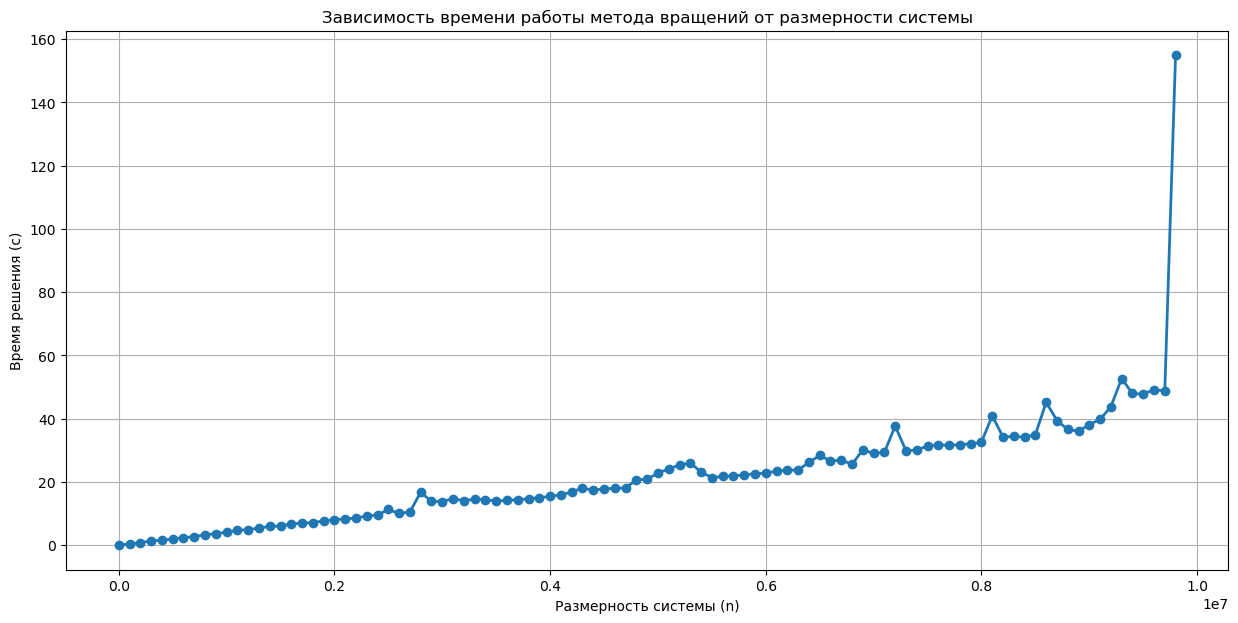

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("timing_results.csv")

plt.figure(figsize=(15,7))
plt.plot(data['dim'], data['time'], 'o-', lw=2)
plt.title("Зависимость времени работы метода вращений от размерности системы")
plt.xlabel("Размерность системы (n)")
plt.ylabel("Время решения (с)")
plt.grid(True)
plt.show()